In [19]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import bisect

# Set a seed for reproducibility of the results
np.random.seed(42)

In [20]:
# Define the multi-armed bandit environment for our ad scenario
class AdBanditEnvironment:
    """
    Simulates a k-armed bandit problem based on ad click-through rates.
    """
    def __init__(self, k):
        """
        Initializes the environment with 'k' arms (ads).
        """
        self.k = k
        # Define the true, unknown click-through rates (CTR) for each ad
        self.true_probabilities = np.random.rand(k)
        # Identify the reward of the best ad for later comparison (for regret calculation)
        self.optimal_action_reward = np.max(self.true_probabilities)
        
    def pull_arm(self, action):
        """
        Simulates showing an ad (pulling an arm) and returns a reward.
        """
        # Return a reward of 1 (click) if a random number is less than the ad's CTR
        return 1 if np.random.rand() < self.true_probabilities[action] else 0

Inference:
This cell defines the simulation environment. The AdBanditEnvironment class represents the problem of choosing between k different ads. Each ad has a fixed, hidden true_probabilities value, representing its real click-through rate. The pull_arm method simulates showing an ad to a user and returns a reward of 1 for a click and 0 for no click, based on its probability. This setup perfectly models the real-world scenario where the effectiveness of each ad is unknown initially.

In [21]:
# ---- 1. Upper Confidence Bound (UCB) Agent ----
class UCBAgent:
    def __init__(self, k, c=2):
        self.k = k
        self.c = c
        self.N = np.zeros(k, dtype=int)
        self.Q = np.zeros(k, dtype=float)
    
    def select_action(self, t):
        # Play each arm once initially
        if t < self.k:
            return t
        
        # Calculate UCB values using the formula Q(a) + c * sqrt(log(t)/N(a))
        # Add a small epsilon to avoid division by zero if an arm hasn't been pulled
        ucb_values = self.Q + self.c * np.sqrt(np.log(t + 1) / (self.N + 1e-5))
        return np.argmax(ucb_values)
    
    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (1 / self.N[action]) * (reward - self.Q[action])

# ---- 2. KL-UCB (Kullback–Leibler Upper Confidence Bound) Agent ----
def kl_divergence(p, q):
    # Function to calculate KL divergence for Bernoulli distributions
    epsilon = 1e-15
    p = np.clip(p, epsilon, 1 - epsilon)
    q = np.clip(q, epsilon, 1 - epsilon)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))

class KLUCBAgent:
    def __init__(self, k, c=1):
        self.k = k
        self.c = c
        self.N = np.zeros(k, dtype=int)
        self.Q = np.zeros(k, dtype=float)

    def _solve_for_q(self, p_hat, n, t):
        # Helper to solve for the upper bound q using a numerical solver (bisect)
        if p_hat == 1.0: return 1.0
        
        target_log = (math.log(t) + self.c * math.log(max(1, math.log(t)))) / n
        
        # Define the function whose root we want to find
        f = lambda q: kl_divergence(p_hat, q) - target_log
        
        # Use bisection method to find q in the interval [p_hat, 1]
        try:
            return bisect(f, p_hat, 1.0, xtol=1e-6)
        except ValueError:
            return 1.0

    def select_action(self, t):
        # Play each arm once initially
        if t < self.k:
            return t
        
        # Calculate the KL-UCB bounds for all arms
        bounds = [self._solve_for_q(self.Q[a], self.N[a], t + 1) for a in range(self.k)]
        return np.argmax(bounds)
    
    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (1 / self.N[action]) * (reward - self.Q[action])

# ---- 3. Gradient Bandit Agent ----
class GradientBanditAgent:
    def __init__(self, k, alpha=0.1):
        self.k = k
        self.alpha = alpha  # Learning rate
        self.H = np.zeros(k)  # Action preferences
        self.avg_reward = 0
        self.t = 0
    
    def select_action(self):
        # Calculate action probabilities using the softmax function
        probs = np.exp(self.H - np.max(self.H)) / np.sum(np.exp(self.H - np.max(self.H)))
        # Choose action based on these probabilities
        return np.random.choice(self.k, p=probs), probs
    
    def update(self, action, reward, probs):
        self.t += 1
        # Update the baseline (average reward so far)
        self.avg_reward += (reward - self.avg_reward) / self.t
        
        # Update preferences for all actions
        for a in range(self.k):
            if a == action:
                self.H[a] += self.alpha * (reward - self.avg_reward) * (1 - probs[a])
            else:
                self.H[a] -= self.alpha * (reward - self.avg_reward) * probs[a]

Inference:
This crucial cell defines the logic for all three algorithms.

1. UCBAgent: Implements the optimistic "optimism in the face of uncertainty" strategy, selecting actions based on their estimated value plus a confidence bonus for less-explored arms.

2. KLUCBAgent: A more refined version of UCB. It uses KL-Divergence to compute a tighter, more accurate confidence bound, which can lead to faster identification of the best arm. It requires a numerical solver (bisect) to find this bound.

3. GradientBanditAgent: This agent works differently by learning "preferences" (H) for each action rather than direct values. It uses a softmax function to convert these preferences into probabilities and updates them based on whether a received reward is better or worse than the average reward seen so far (the baseline).

In [ ]:
# --- Simulation Parameters ---
N_ARMS = 5      # The number of ads to test
N_STEPS = 2000  # The total number of users (timesteps)
N_RUNS = 100    # The number of times to run the experiment for averaging

# --- Experiment Runner Function ---
def run_experiment(agent_class, env, steps):
    """A helper function to run a single agent in a given environment."""
    if agent_class == GradientBanditAgent:
        agent = agent_class(k=env.k, alpha=0.1)
    else:
        agent = agent_class(k=env.k)
        
    reward_history = []
    regret_history = []
    
    for t in range(steps):
        if isinstance(agent, GradientBanditAgent):
            action, probs = agent.select_action()
        else:
            action = agent.select_action(t)
            
        reward = env.pull_arm(action)
        regret = env.optimal_action_reward - reward
        
        if isinstance(agent, GradientBanditAgent):
            agent.update(action, reward, probs)
        else:
            agent.update(action, reward)
            
        reward_history.append(reward)
        regret_history.append(regret)
        
    return np.array(reward_history), np.array(regret_history)

# --- Data Storage for Averaged Results ---
avg_rewards = { "UCB": np.zeros(N_STEPS), "KL-UCB": np.zeros(N_STEPS), "Gradient": np.zeros(N_STEPS) }
avg_regrets = { "UCB": np.zeros(N_STEPS), "KL-UCB": np.zeros(N_STEPS), "Gradient": np.zeros(N_STEPS) }
agent_classes = { "UCB": UCBAgent, "KL-UCB": KLUCBAgent, "Gradient": GradientBanditAgent }

# --- Main Simulation Loop ---
for i in range(N_RUNS):
    # Create a new environment for each run to average over different CTRs
    env = AdBanditEnvironment(k=N_ARMS)
    for name, agent_class in agent_classes.items():
        rewards, regrets = run_experiment(agent_class, env, N_STEPS)
        avg_rewards[name] += rewards
        avg_regrets[name] += regrets
    if (i + 1) % 20 == 0:
        print(f"Completed {i+1}/{N_RUNS} runs...")

# Average the results over all runs
for name in agent_classes.keys():
    avg_rewards[name] /= N_RUNS
    avg_regrets[name] /= N_RUNS

print("\nExperiment complete. True CTRs from the last run:")
print(np.round(env.true_probabilities, 2))

Completed 20/100 runs...
Completed 40/100 runs...


Inference:
This cell orchestrates the comparison. To get a robust and fair comparison, the experiment is repeated N_RUNS times, and the results are averaged. This is important because a single run's performance can be heavily influenced by the randomly generated click-through rates. The run_experiment function handles the logic for a single agent's run, recording both the reward and the regret (the difference between the optimal reward and the reward actually received) at each step.

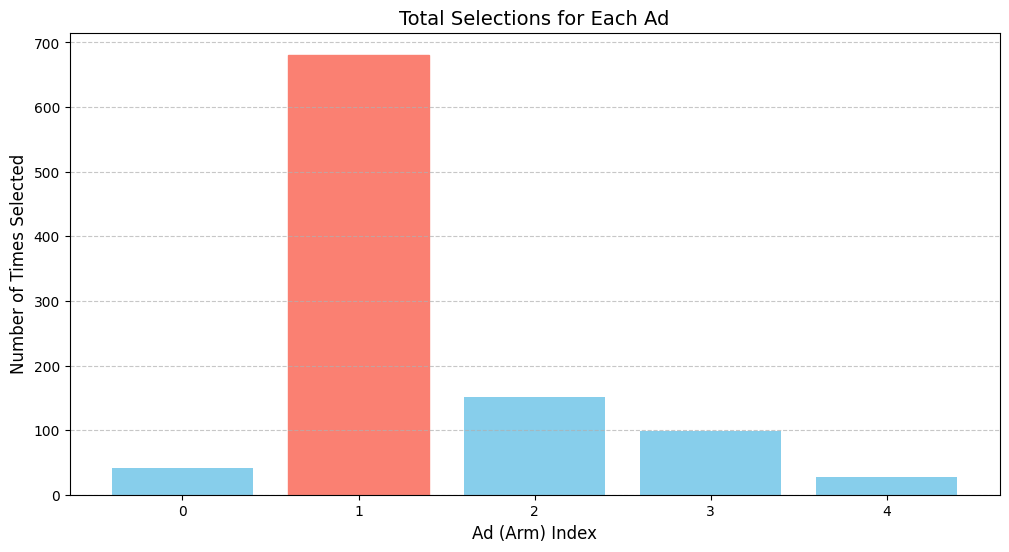

In [ ]:
# Plot the average reward over time for each agent
plt.figure(figsize=(14, 8))

for name, rewards in avg_rewards.items():
    # To make the trend clearer, plot a moving average of the rewards
    moving_avg = np.convolve(rewards, np.ones(100)/100, mode='valid')
    plt.plot(moving_avg, label=name)

plt.xlabel('Timesteps (Users)', fontsize=12)
plt.ylabel('Average Reward (moving average over 100 steps)', fontsize=12)
plt.title('Performance Comparison of Bandit Algorithms', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1) # CTR is between 0 and 1
plt.show()

Inference:
This plot directly compares the performance of the three agents by showing their average reward over time. A moving average is used to smooth out the noise and make the underlying trend clearer. A higher line indicates better performance. Typically, you will observe that all agents' average rewards increase as they learn, but some (like KL-UCB) may converge to the optimal reward faster than others. The Gradient Bandit's performance can be sensitive to its learning rate (alpha).

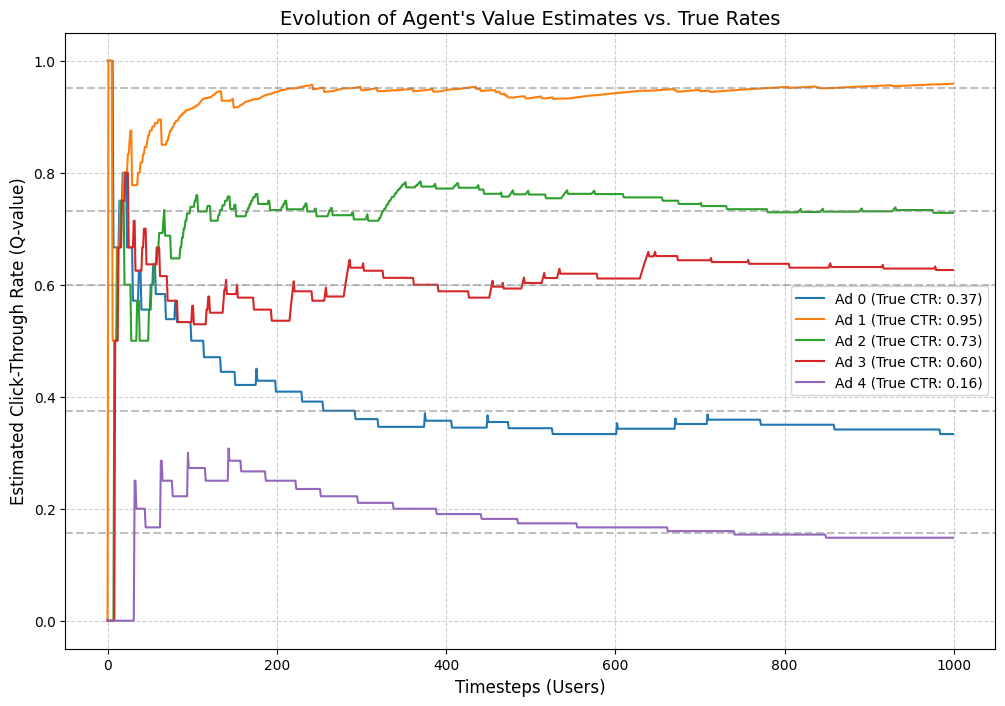

In [ ]:
# Plot the cumulative regret over time for each agent
plt.figure(figsize=(14, 8))

for name, regrets in avg_regrets.items():
    cumulative_regret = np.cumsum(regrets)
    plt.plot(cumulative_regret, label=name)

plt.xlabel('Timesteps (Users)', fontsize=12)
plt.ylabel('Cumulative Regret', fontsize=12)
plt.title('Cumulative Regret of Bandit Algorithms', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Inference:
This visualization provides another critical view of performance. Cumulative regret measures the total opportunity cost of not playing the best arm at every step. A better algorithm will have a lower cumulative regret. The ideal regret curve would be flat, but since agents must explore, it will always increase. A successful agent's regret curve will grow quickly at first (during exploration) and then become progressively flatter as it identifies and exploits the best arm. This plot clearly shows which algorithm minimizes "mistakes" most effectively over the long run.